# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4166s 24us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

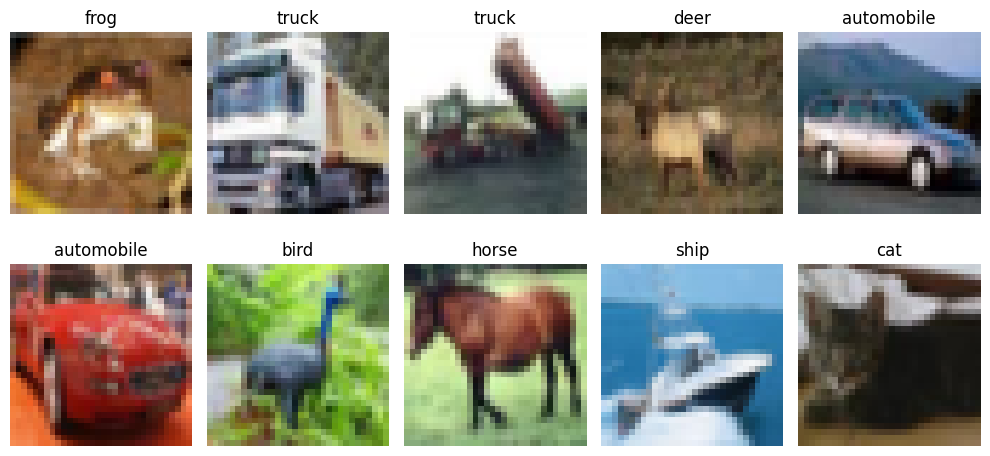

In [3]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [4]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [5]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 25s 33ms/step - accuracy: 0.2761 - loss: 1.9947 - val_accuracy: 0.3628 - val_loss: 1.8191
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 25s 36ms/step - accuracy: 0.3220 - loss: 1.8628 - val_accuracy: 0.3540 - val_loss: 1.8082
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 38s 32ms/step - accuracy: 0.3465 - loss: 1.8018 - val_accuracy: 0.3812 - val_loss: 1.7356
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 40s 30ms/step - accuracy: 0.3593 - loss: 1.7652 - val_accuracy: 0.3890 - val_loss: 1.7113
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - accuracy: 0.3655 - loss: 1.7441 - val_accuracy: 0.4052 - val_loss: 1.6780
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.3781 - loss: 1.7126 - val_accuracy: 0.4134 - val_loss: 1.6666
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.3816 - loss: 1.7028 - val_accuracy: 0.3980 - val_loss: 1.6723
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - accuracy: 0.3845 - loss: 1.6925 - 

In [6]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4429 - loss: 1.6085
ANN Test Accuracy: 0.44290000200271606


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [7]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 90s 123ms/step - accuracy: 0.4696 - loss: 1.4811 - val_accuracy: 0.5786 - val_loss: 1.1711
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 88s 126ms/step - accuracy: 0.6106 - loss: 1.1093 - val_accuracy: 0.5978 - val_loss: 1.1551
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 85s 121ms/step - accuracy: 0.6770 - loss: 0.9257 - val_accuracy: 0.6366 - val_loss: 1.0275
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 143s 122ms/step - accuracy: 0.7174 - loss: 0.8086 - val_accuracy: 0.6880 - val_loss: 0.9056
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 146s 127ms/step - accuracy: 0.7501 - loss: 0.7205 - val_accuracy: 0.7070 - val_loss: 0.8662
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 142s 127ms/step - accuracy: 0.7770 - loss: 0.6395 - val_accuracy: 0.6816 - val_loss: 0.9274
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 86s 122ms/step - accuracy: 0.7984 - loss: 0.5715 - val_accuracy: 0.6954 - val_loss: 0.9158
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 141s 122ms/step - accuracy: 0.8174 - los

In [8]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.7216 - loss: 0.9281
CNN Test Accuracy: 0.7215999960899353


## 📈 Compare Learning Curves

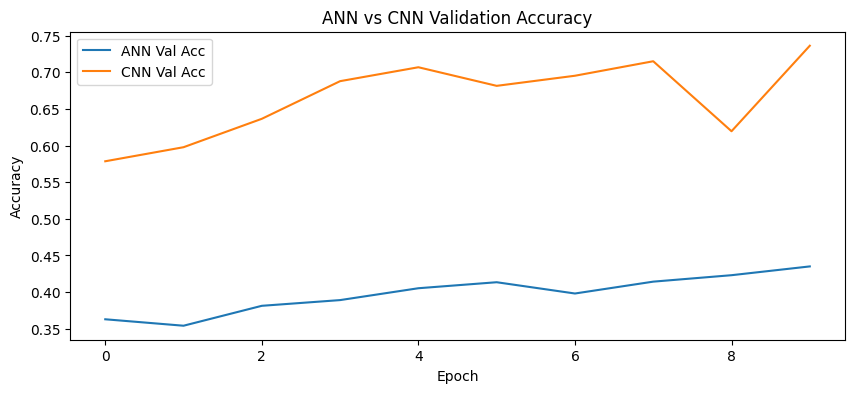

In [9]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [10]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

# Suggested optional run:
# aug_history = aug_cnn_model.fit(x_train_norm, y_train, epochs=10, validation_split=0.1)

# 📊 Final Comparison Table

In [11]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc]
})
comparison

,Model,Test Accuracy
0,ANN,0.4429
1,CNN,0.7216


# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**

# Student Learning Tasks

In [12]:
# 1. Increase ANN layers and observe performance



ann_model = models.Sequential([
    layers.Flatten(input_shape=(32,32,3)),

    layers.Dense(1024, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(256, activation='relu'),

    layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [13]:

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)




ann_history = ann_model.fit(
    x_train_norm,
    y_train,
    epochs=20,
    validation_split=0.2
)

Epoch 1/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 80s 62ms/step - accuracy: 0.2444 - loss: 2.0351 - val_accuracy: 0.3163 - val_loss: 1.8789
Epoch 2/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 72s 57ms/step - accuracy: 0.2916 - loss: 1.9147 - val_accuracy: 0.3226 - val_loss: 1.8715
Epoch 3/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 84s 59ms/step - accuracy: 0.3077 - loss: 1.8735 - val_accuracy: 0.3220 - val_loss: 1.8601
Epoch 4/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 73s 58ms/step - accuracy: 0.3134 - loss: 1.8551 - val_accuracy: 0.3392 - val_loss: 1.8225
Epoch 5/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 70s 56ms/step - accuracy: 0.3209 - loss: 1.8373 - val_accuracy: 0.3612 - val_loss: 1.7900
Epoch 6/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 83s 57ms/step - accuracy: 0.3260 - loss: 1.8256 - val_accuracy: 0.3581 - val_loss: 1.7750
Epoch 7/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 89s 62ms/step - accuracy: 0.3329 - loss: 1.8151 - val_accuracy: 0.3550 - val_loss: 1.7706
Epoch 8/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 75s 60ms/step - accuracy: 0.3392 -

In [14]:
# 2. Change CNN filters from 32→64→128

cnn_model = models.Sequential([

    layers.Conv2D(32,(3,3),activation='relu',input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(128,activation='relu'),

    layers.Dense(10,activation='softmax')

])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [15]:
cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [16]:
# 3. Increase epochs to 20


cnn_history = cnn_model.fit(

    x_train_norm,

    y_train,

    epochs=20,

    validation_split=0.2

)

Epoch 1/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 68s 52ms/step - accuracy: 0.4374 - loss: 1.5365 - val_accuracy: 0.5395 - val_loss: 1.3060
Epoch 2/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 60s 48ms/step - accuracy: 0.5907 - loss: 1.1552 - val_accuracy: 0.6048 - val_loss: 1.1255
Epoch 3/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 80s 47ms/step - accuracy: 0.6536 - loss: 0.9911 - val_accuracy: 0.6718 - val_loss: 0.9649
Epoch 4/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 56s 45ms/step - accuracy: 0.6941 - loss: 0.8763 - val_accuracy: 0.6628 - val_loss: 1.0043
Epoch 5/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 83s 46ms/step - accuracy: 0.7274 - loss: 0.7852 - val_accuracy: 0.6824 - val_loss: 0.9327
Epoch 6/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 58s 46ms/step - accuracy: 0.7495 - loss: 0.7110 - val_accuracy: 0.6937 - val_loss: 0.9212
Epoch 7/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 81s 46ms/step - accuracy: 0.7699 - loss: 0.6525 - val_accuracy: 0.7186 - val_loss: 0.8543
Epoch 8/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 82s 46ms/step - accuracy: 0.7920 -

In [17]:
# 4. Add EarlyStopping


from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(

    monitor="val_loss",

    patience=3,

    restore_best_weights=True
)

In [18]:
cnn_history = cnn_model.fit(

    x_train_norm,

    y_train,

    epochs=20,

    validation_split=0.2,

    callbacks=[early_stop]

)

Epoch 1/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 57s 45ms/step - accuracy: 0.9368 - loss: 0.1772 - val_accuracy: 0.7093 - val_loss: 1.5215
Epoch 2/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 83s 46ms/step - accuracy: 0.9417 - loss: 0.1631 - val_accuracy: 0.7075 - val_loss: 1.5985
Epoch 3/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 81s 45ms/step - accuracy: 0.9451 - loss: 0.1557 - val_accuracy: 0.7037 - val_loss: 1.6960
Epoch 4/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 83s 46ms/step - accuracy: 0.9485 - loss: 0.1432 - val_accuracy: 0.7056 - val_loss: 1.7060


In [ ]:
# 5. data_augmentation = tf.keras.Sequential([

layers.RandomFlip("horizontal"),

layers.RandomRotation(0.1),

layers.RandomZoom(0.2),

layers.RandomContrast(0.2)

In [ ]:
cnn_model = models.Sequential([

    data_augmentation,

    layers.Conv2D(32,(3,3),activation='relu'),

    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64,(3,3),activation='relu'),

    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128,(3,3),activation='relu'),

    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(128,activation='relu'),

    layers.Dense(10,activation='softmax')

])

In [23]:
cnn_model.compile(

    optimizer="adam",

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]

)

In [22]:
cnn_history = cnn_model.fit(x_train_norm,y_train,epochs=20,validation_split=0.2,callbacks=[early_stop])

Epoch 1/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 71s 55ms/step - accuracy: 0.3860 - loss: 1.6755 - val_accuracy: 0.4320 - val_loss: 1.6227
Epoch 2/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 67s 54ms/step - accuracy: 0.4984 - loss: 1.3931 - val_accuracy: 0.5252 - val_loss: 1.3835
Epoch 3/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 81s 53ms/step - accuracy: 0.5472 - loss: 1.2744 - val_accuracy: 0.6029 - val_loss: 1.1252
Epoch 4/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 82s 54ms/step - accuracy: 0.5737 - loss: 1.1972 - val_accuracy: 0.5981 - val_loss: 1.1658
Epoch 5/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 66s 53ms/step - accuracy: 0.5937 - loss: 1.1481 - val_accuracy: 0.6240 - val_loss: 1.0747
Epoch 6/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 68s 54ms/step - accuracy: 0.6097 - loss: 1.1055 - val_accuracy: 0.6361 - val_loss: 1.0384
Epoch 7/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 66s 53ms/step - accuracy: 0.6274 - loss: 1.0592 - val_accuracy: 0.6248 - val_loss: 1.1047
Epoch 8/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 83s 53ms/step - accuracy: 0.6397 -

## Expected Results

| Task | Expected Result |
|------|-----------------|
| **Increase ANN layers** | Slight improvement in ANN accuracy. |
| **CNN filters (32 → 64 → 128)** | Better feature extraction and improved CNN accuracy. |
| **Epochs = 20** | Model gets more time to learn, but watch for overfitting. |
| **EarlyStopping** | Stops training automatically when the validation loss stops improving. |
| **Data Augmentation** | Improves generalization and helps reduce overfitting. |